# Лабораторная работа №2
## Виртуальный датчик для контроля процесса обжига в печи

Цель работы — построить виртуальный датчик, который оценивает текущее значение концентрации выходного продукта по минутной телеметрии печи, несмотря на то, что лабораторный результат приходит нерегулярно и с задержкой 10–15 минут.

В работе выполняются:
1. EDA телеметрии и лабораторных замеров
2. Синхронизация телеметрии и target с учетом задержки
3. Инжиниринг временных признаков
4. Обучение нескольких моделей
5. Оценка качества моделей
6. Анализ остатков и важности признаков
7. Итоговые аналитические выводы

In [2]:
import warnings
warnings.filterwarnings("ignore")

from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [3]:
DATA_TRAIN_PATH = "data_train.csv"
TARGET_TRAIN_PATH = "target_train.csv"
DATA_TEST_PATH = "data_test_small.csv"
TARGET_TEST_PATH = "target_test_small.csv"

data_train = pd.read_csv(DATA_TRAIN_PATH, parse_dates=["datetime"])
target_train = pd.read_csv(TARGET_TRAIN_PATH, parse_dates=["Дата"]).rename(columns={"Дата": "datetime"})

data_test = pd.read_csv(DATA_TEST_PATH, parse_dates=["datetime"])
target_test = pd.read_csv(TARGET_TEST_PATH, parse_dates=["Дата"]).rename(columns={"Дата": "datetime"})

print("Raw shapes:")
print("data_train:", data_train.shape)
print("target_train:", target_train.shape)
print("data_test:", data_test.shape)
print("target_test:", target_test.shape)

print("\nColumns in data_train:")
print(data_train.columns.tolist())

print("\nColumns in target_train:")
print(target_train.columns.tolist())

Raw shapes:
data_train: (319546, 17)
target_train: (1773, 2)
data_test: (39943, 17)
target_test: (318, 2)

Columns in data_train:
['datetime', 'telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7', 'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11', 'telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']

Columns in target_train:
['datetime', 'target']


### Базовая диагностика временной структуры

In [5]:
def describe_timeframe(df, time_col="datetime"):
    diffs = df[time_col].sort_values().diff().dropna()
    return pd.Series({
        "start": df[time_col].min(),
        "end": df[time_col].max(),
        "rows": len(df),
        "median_diff_min": diffs.median() / pd.Timedelta(minutes=1) if len(diffs) else np.nan,
        "max_gap_min": diffs.max() / pd.Timedelta(minutes=1) if len(diffs) else np.nan,
        "duplicates": int(df[time_col].duplicated().sum())
    })

summary = pd.concat(
    {
        "data_train": describe_timeframe(data_train),
        "target_train": describe_timeframe(target_train),
        "data_test": describe_timeframe(data_test),
        "target_test": describe_timeframe(target_test),
    },
    axis=1
)

summary

,data_train,target_train,data_test,target_test
start,2019-03-01 00:01:00,2019-03-13 17:00:00,2019-10-07 19:59:00,2019-10-07 23:00:00
end,2019-10-07 19:58:00,2019-10-07 21:00:00,2019-11-04 10:25:00,2019-11-04 09:00:00
rows,319546,1773,39943,318
median_diff_min,1.0,120.0,1.0,120.0
max_gap_min,1.0,26430.0,1.0,1080.0
duplicates,1548,0,196,0


### Проверим на дупликаты

In [6]:
def aggregate_minute_duplicates(df):
    value_cols = [c for c in df.columns if c != "datetime"]
    return df.groupby("datetime", as_index=False)[value_cols].mean()

data_train = aggregate_minute_duplicates(data_train)
data_test = aggregate_minute_duplicates(data_test)

print("After deduplication:")
print("data_train:", data_train.shape, "duplicates:", data_train["datetime"].duplicated().sum())
print("data_test :", data_test.shape, "duplicates:", data_test["datetime"].duplicated().sum())

After deduplication:
data_train: (317998, 17) duplicates: 0
data_test : (39747, 17) duplicates: 0


### Аналитический вывод по первичной диагностике

1. Временная структура телеметрии приведена к корректному минутному ряду.
2. Проверка на дубликаты timestamp выполнена; при необходимости они агрегируются по среднему.

In [8]:
telemetry_cols = [c for c in data_train.columns if c.startswith("telemetry_")]
missing_ratio = data_train[telemetry_cols].isna().mean().sort_values(ascending=False)

missing_ratio.to_frame("missing_ratio")

,missing_ratio
telemetry_12,0.993406
telemetry_13,0.993406
telemetry_14,0.993406
telemetry_15,0.993406
telemetry_4,0.000418
telemetry_0,0.000053
telemetry_5,0.000053
telemetry_1,0.000050
telemetry_7,0.000050
telemetry_6,0.000050


In [9]:
sparse_cols = [c for c in telemetry_cols if data_train[c].isna().mean() > 0.9]
dense_cols = [c for c in telemetry_cols if c not in sparse_cols]

print("Dense channels:", dense_cols)
print("Sparse channels:", sparse_cols)

Dense channels: ['telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7', 'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11']
Sparse channels: ['telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']


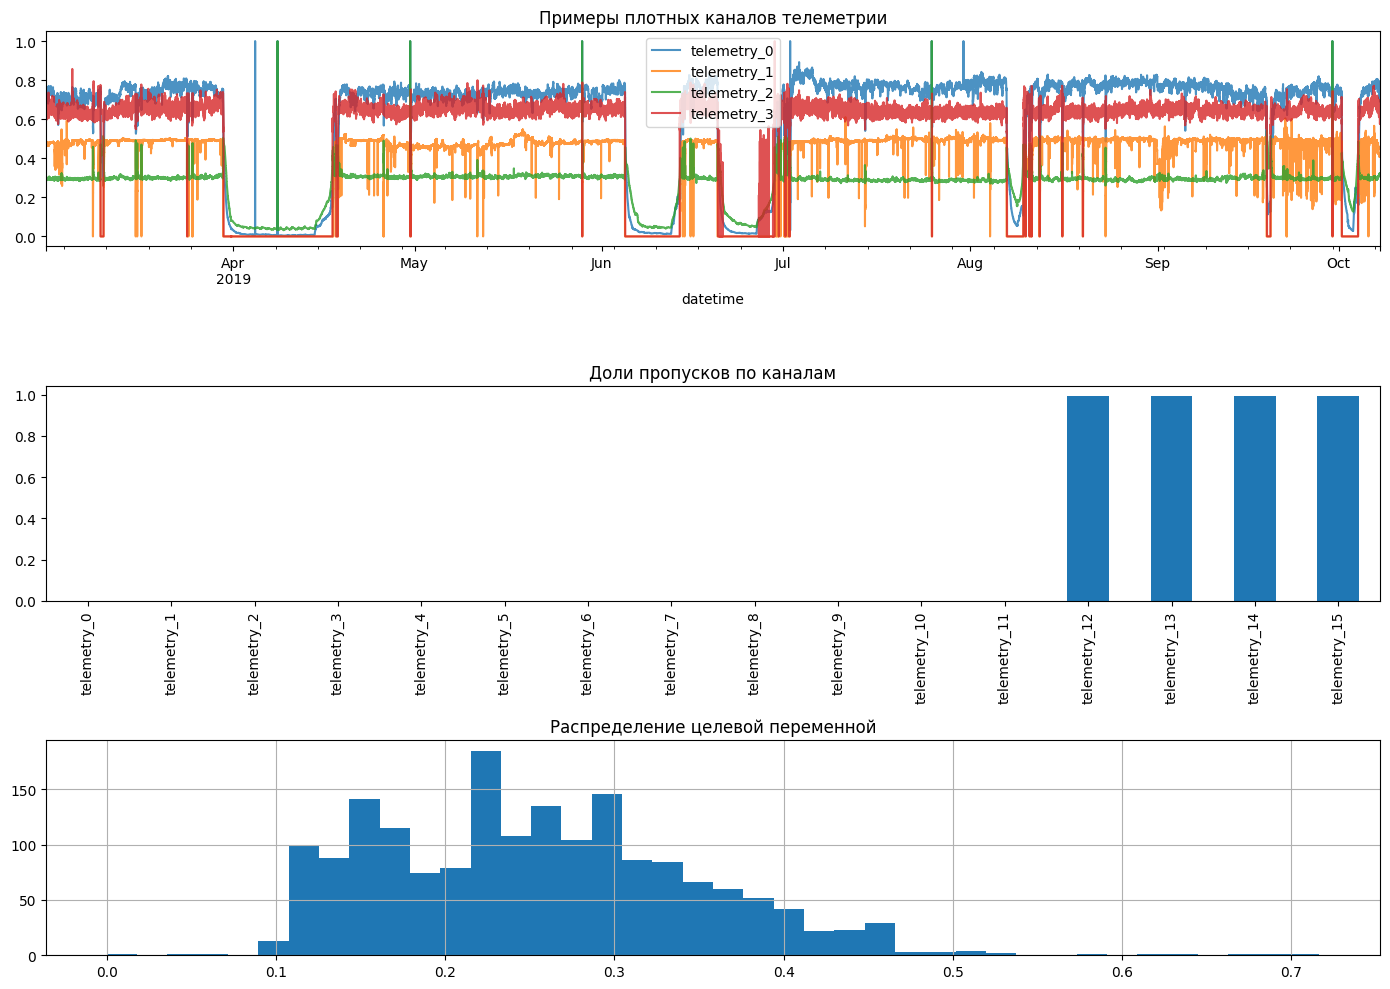

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for col in dense_cols[:4]:
    data_train.plot(x="datetime", y=col, ax=axes[0], alpha=0.8, legend=True)
axes[0].set_title("Примеры плотных каналов телеметрии")

missing_ratio.loc[dense_cols + sparse_cols].plot(kind="bar", ax=axes[1])
axes[1].set_title("Доли пропусков по каналам")

target_train["target"].hist(bins=40, ax=axes[2])
axes[2].set_title("Распределение целевой переменной")

plt.tight_layout()
plt.show()

In [11]:
target_train = target_train.sort_values("datetime").copy()
target_train["gap_min"] = target_train["datetime"].diff().dt.total_seconds() / 60

target_train["gap_min"].describe()

,gap_min
count,1772.000000
mean,169.164786
std,784.088290
min,60.000000
25%,120.000000
50%,120.000000
75%,120.000000
max,26430.000000


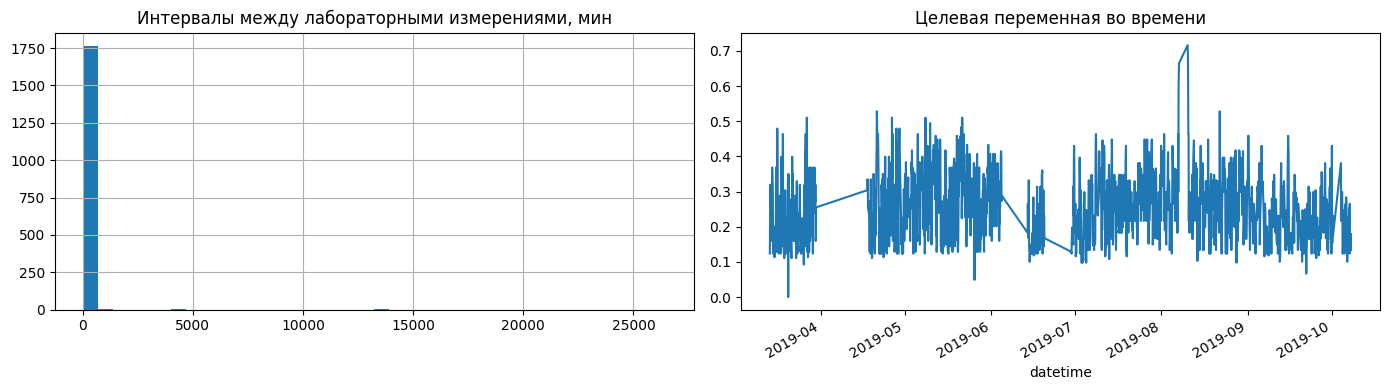

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

target_train["gap_min"].dropna().hist(bins=40, ax=axes[0])
axes[0].set_title("Интервалы между лабораторными измерениями, мин")

target_train.plot(x="datetime", y="target", ax=axes[1], legend=False)
axes[1].set_title("Целевая переменная во времени")

plt.tight_layout()
plt.show()

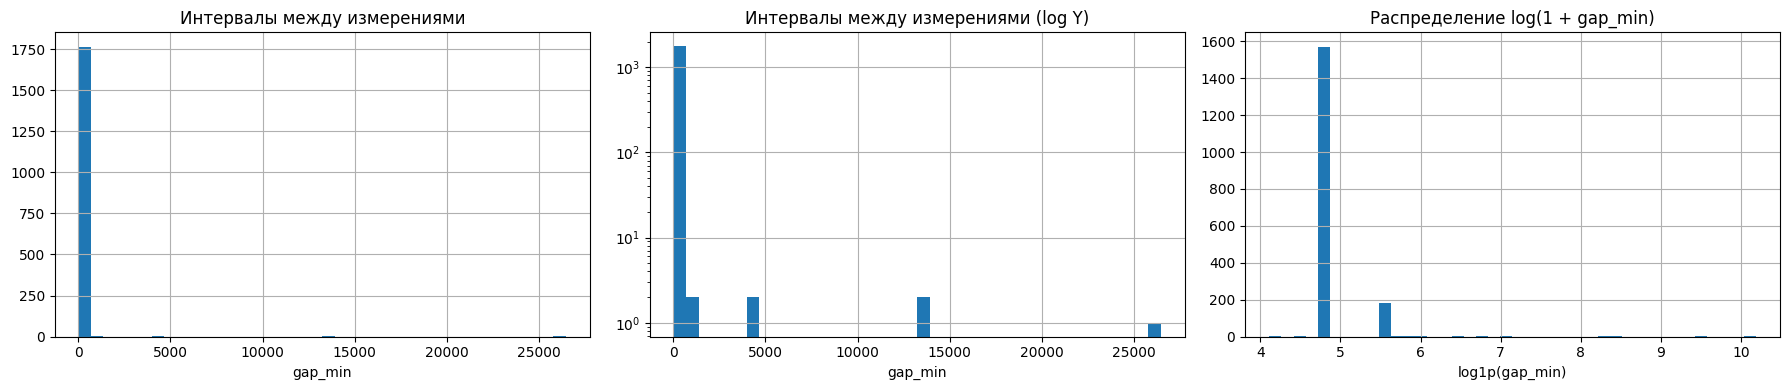

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Обычная гистограмма
target_train["gap_min"].dropna().hist(bins=40, ax=axes[0])
axes[0].set_title("Интервалы между измерениями")
axes[0].set_xlabel("gap_min")

# 2. Та же гистограмма, но лог по оси Y
target_train["gap_min"].dropna().hist(bins=40, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Интервалы между измерениями (log Y)")
axes[1].set_xlabel("gap_min")

# 3. Гистограмма log1p(gap_min)
np.log1p(target_train["gap_min"].dropna()).hist(bins=40, ax=axes[2])
axes[2].set_title("Распределение log(1 + gap_min)")
axes[2].set_xlabel("log1p(gap_min)")

plt.tight_layout()
plt.show()

In [14]:
target_train["gap_min"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]) # самые большие разрывы

,gap_min
count,1772.000000
mean,169.164786
std,784.088290
min,60.000000
50%,120.000000
90%,240.000000
95%,240.000000
99%,240.000000
max,26430.000000


In [15]:
target_train.sort_values("gap_min", ascending=False).head(10)

,datetime,target,gap_min
191,2019-04-17 15:00:00,0.304124,26430.0
833,2019-06-29 17:00:00,0.128866,13800.0
759,2019-06-14 01:00:00,0.182990,13320.0
1256,2019-08-10 09:00:00,0.716495,4440.0
1729,2019-10-04 07:00:00,0.381443,4080.0
1590,2019-09-19 21:00:00,0.149485,1200.0
328,2019-04-29 21:00:00,0.149485,840.0
196,2019-04-18 10:00:00,0.224227,660.0
1224,2019-08-04 09:00:00,0.265464,600.0
839,2019-06-30 10:00:00,0.149485,420.0


### Аналитический вывод по EDA

1. Телеметрия состоит из плотных и крайне разреженных каналов.
2. Целевая переменная измеряется нерегулярно, в основном с интервалом около 120 минут.
3. Задача относится к классу virtual sensing / soft sensor: нужно восстановить текущее качество по состоянию процесса.
4. Плотные и редкие каналы требуют разной стратегии обработки пропусков.

## Синхронизация источников

Лаборатория возвращает результат не в момент отбора пробы, а через 10–15 минут.

Обозначим:
- `lab_time` — время появления результата лаборатории,
- `delay` — задержка анализа,
- `process_time = lab_time - delay`.

Именно `process_time` соответствует реальному моменту, для которого нужно брать телеметрию и строить признаки.

In [16]:
def align_target_to_process_time(target_df, delay_minutes):
    out = target_df.copy()
    out["process_time"] = out["datetime"] - pd.to_timedelta(delay_minutes, unit="m")
    return out

align_target_to_process_time(target_train, 12).head()

,datetime,target,gap_min,process_time
0,2019-03-13 17:00:00,0.123711,NaN,2019-03-13 16:48:00
1,2019-03-13 21:00:00,0.319588,240.0,2019-03-13 20:48:00
2,2019-03-14 01:00:00,0.255155,240.0,2019-03-14 00:48:00
3,2019-03-14 05:00:00,0.319588,240.0,2019-03-14 04:48:00
4,2019-03-14 09:00:00,0.159794,240.0,2019-03-14 08:48:00


In [17]:
def lag_correlation_scan(data_df, target_df, feature_cols, max_lag=60):
    rows = []
    data_idx = data_df.set_index("datetime")

    for col in feature_cols:
        s = data_idx[col]
        for lag in range(max_lag + 1):
            vals = s.reindex(target_df["datetime"] - pd.to_timedelta(lag, unit="m")).values
            corr = pd.Series(vals).corr(target_df["target"])
            rows.append({
                "feature": col,
                "lag_min": lag,
                "corr": corr,
                "abs_corr": abs(corr) if pd.notna(corr) else np.nan
            })
    return pd.DataFrame(rows)

lag_corr = lag_correlation_scan(data_train, target_train, dense_cols, max_lag=60)
lag_corr.sort_values("abs_corr", ascending=False).head(20)

,feature,lag_min,corr,abs_corr
0,telemetry_0,0,-0.187022,0.187022
1,telemetry_0,1,-0.186671,0.186671
5,telemetry_0,5,-0.186639,0.186639
2,telemetry_0,2,-0.186311,0.186311
3,telemetry_0,3,-0.186074,0.186074
4,telemetry_0,4,-0.185893,0.185893
7,telemetry_0,7,-0.185824,0.185824
8,telemetry_0,8,-0.185609,0.185609
6,telemetry_0,6,-0.185424,0.185424
9,telemetry_0,9,-0.184897,0.184897


In [18]:
top_lag_features = (
    lag_corr.groupby("feature")["abs_corr"]
    .max()
    .sort_values(ascending=False)
    .head(8)
    .index
    .tolist()
)

top_lag_features

['telemetry_0',
 'telemetry_3',
 'telemetry_9',
 'telemetry_6',
 'telemetry_8',
 'telemetry_4',
 'telemetry_11',
 'telemetry_5']

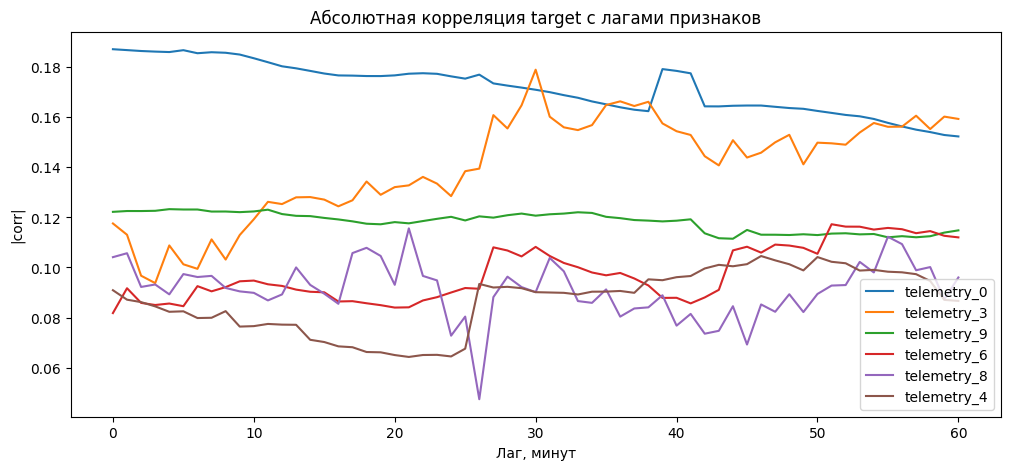

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

for feature in top_lag_features[:6]:
    part = lag_corr[lag_corr["feature"] == feature]
    ax.plot(part["lag_min"], part["abs_corr"], label=feature)

ax.set_title("Абсолютная корреляция target с лагами признаков")
ax.set_xlabel("Лаг, минут")
ax.set_ylabel("|corr|")
ax.legend()
plt.show()

### Аналитический вывод по синхронизации и лагам

1. Таргет необходимо сдвигать назад на 10–15 минут, иначе возникает утечка в будущее.
2. Для части телеметрических каналов наиболее информативны лаги, а не мгновенные значения.
3. Это указывает на инерционный характер процесса обжига и оправдывает использование lag- и rolling-признаков.

In [20]:
def prepare_minute_telemetry(df, dense_cols, sparse_cols):
    df = df.sort_values("datetime").copy()

    # Плотные каналы: мягко восстанавливаем короткие пропуски
    df[dense_cols] = df[dense_cols].interpolate(limit=5).ffill().bfill()

    # Редкие каналы: последнее известное значение + возраст значения
    for col in sparse_cols:
        mask = df[col].notna()
        last_time = df["datetime"].where(mask).ffill()
        df[f"{col}_ffill"] = df[col].ffill()
        df[f"{col}_age_min"] = (df["datetime"] - last_time).dt.total_seconds() / 60

    # Календарные признаки
    df["hour"] = df["datetime"].dt.hour
    df["dayofweek"] = df["datetime"].dt.dayofweek
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    return df

minute_train = prepare_minute_telemetry(data_train, dense_cols, sparse_cols)
minute_test = prepare_minute_telemetry(data_test, dense_cols, sparse_cols)

In [21]:
key_dense_cols = top_lag_features[:8]
key_dense_cols # ключивые признаки

['telemetry_0',
 'telemetry_3',
 'telemetry_9',
 'telemetry_6',
 'telemetry_8',
 'telemetry_4',
 'telemetry_11',
 'telemetry_5']

In [22]:
def build_supervised_dataset(
    minute_df,
    target_df,
    delay_minutes=12,
    key_dense_cols=None,
    sparse_cols=None,
    lag_list=(0, 5, 15, 30, 60),
    roll_windows=(5, 15, 30, 60)
):
    key_dense_cols = list(key_dense_cols)
    sparse_cols = list(sparse_cols)

    aligned = target_df.sort_values("datetime").copy()
    aligned["process_time"] = aligned["datetime"] - pd.to_timedelta(delay_minutes, unit="m")
    minute_idx = minute_df.set_index("datetime")

    out = aligned[["datetime", "process_time", "target"]].copy().reset_index(drop=True)
    feature_dict = {}

    base_cols = (
        key_dense_cols
        + [f"{c}_ffill" for c in sparse_cols]
        + [f"{c}_age_min" for c in sparse_cols]
        + ["hour", "dayofweek", "is_weekend"]
    )

    base = minute_idx[base_cols].reindex(aligned["process_time"])
    for col in base_cols:
        feature_dict[col] = base[col].values

    for col in key_dense_cols:
        s = minute_idx[col]
        current = s.reindex(aligned["process_time"]).values

        for lag in lag_list:
            feature_dict[f"{col}_lag_{lag}"] = s.reindex(
                aligned["process_time"] - pd.to_timedelta(lag, unit="m")
            ).values

        for w in roll_windows:
            rolled = s.rolling(w, min_periods=max(2, w // 3))
            feature_dict[f"{col}_rollmean_{w}"] = rolled.mean().reindex(aligned["process_time"]).values
            feature_dict[f"{col}_rollstd_{w}"] = rolled.std().reindex(aligned["process_time"]).values
            feature_dict[f"{col}_rollmin_{w}"] = rolled.min().reindex(aligned["process_time"]).values
            feature_dict[f"{col}_rollmax_{w}"] = rolled.max().reindex(aligned["process_time"]).values

        for lag in (5, 15, 60):
            prev = s.reindex(aligned["process_time"] - pd.to_timedelta(lag, unit="m")).values
            feature_dict[f"{col}_diff_{lag}"] = current - prev
            feature_dict[f"{col}_pct_{lag}"] = (current - prev) / (np.abs(prev) + 1e-6)

    feature_df = pd.DataFrame(feature_dict)
    out = pd.concat([out, feature_df], axis=1)
    return out

In [24]:
delay_scores = []

for delay in range(10, 16):
    ds = build_supervised_dataset(
        minute_train,
        target_train,
        delay_minutes=delay,
        key_dense_cols=key_dense_cols,
        sparse_cols=sparse_cols
    ).sort_values("process_time").reset_index(drop=True)

    feature_cols = [c for c in ds.columns if c not in ["datetime", "process_time", "target"]]

    split_idx = int(len(ds) * 0.8)
    X_train_delay = ds.loc[:split_idx - 1, feature_cols]
    y_train_delay = ds.loc[:split_idx - 1, "target"]
    X_valid_delay = ds.loc[split_idx:, feature_cols]
    y_valid_delay = ds.loc[split_idx:, "target"]

    model = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_depth=5,
        max_iter=250,
        min_samples_leaf=10,
        random_state=42
    )
    model.fit(X_train_delay, y_train_delay)
    pred_valid_delay = model.predict(X_valid_delay)

    delay_scores.append({
        "delay_min": delay,
        "MAE": mean_absolute_error(y_valid_delay, pred_valid_delay),
        "RMSE": np.sqrt(mean_squared_error(y_valid_delay, pred_valid_delay)),
        "R2": r2_score(y_valid_delay, pred_valid_delay),
    })

delay_scores = pd.DataFrame(delay_scores).sort_values("MAE")
delay_scores

,delay_min,MAE,RMSE,R2
4,14,0.065868,0.081400,-0.135600
1,11,0.066474,0.083259,-0.188068
3,13,0.067067,0.083751,-0.202167
0,10,0.067171,0.083523,-0.195621
5,15,0.067393,0.082724,-0.172862
2,12,0.068174,0.084465,-0.222746


In [25]:
best_delay = int(delay_scores.iloc[0]["delay_min"])
print("Best delay:", best_delay)

Best delay: 14


### Аналитический вывод по инжинирингу признаков

1. Для прогноза текущего качества необходимо учитывать историю процесса, а не только текущее состояние.
2. Лаги, rolling statistics и признаки динамики позволяют описать инерционность печи.
3. Для редких каналов более корректна схема `last value + age`, чем линейная интерполяция.
4. PCA в основном решении не используется, так как в этой задаче важна интерпретируемость признаков.

In [27]:
train_ds = build_supervised_dataset(
    minute_train,
    target_train,
    delay_minutes=best_delay,
    key_dense_cols=key_dense_cols,
    sparse_cols=sparse_cols
).sort_values("process_time").reset_index(drop=True)

test_ds = build_supervised_dataset(
    minute_test,
    target_test,
    delay_minutes=best_delay,
    key_dense_cols=key_dense_cols,
    sparse_cols=sparse_cols
).sort_values("process_time").reset_index(drop=True)

feature_cols = [c for c in train_ds.columns if c not in ["datetime", "process_time", "target"]]

split_idx = int(len(train_ds) * 0.8)

X_train = train_ds.loc[:split_idx - 1, feature_cols]
y_train = train_ds.loc[:split_idx - 1, "target"]

X_valid = train_ds.loc[split_idx:, feature_cols]
y_valid = train_ds.loc[split_idx:, "target"]

X_test = test_ds[feature_cols]
y_test = test_ds["target"]

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test :", X_test.shape)

Train: (1418, 235)
Valid: (355, 235)
Test : (318, 235)


## Выбор моделей

### Подходящие модели
1. **ElasticNet**  
   Подходит как регуляризованный линейный baseline при большом числе лагов и высокой мультиколлинеарности.

2. **RandomForestRegressor**  
   Подходит для улавливания нелинейных зависимостей и взаимодействий признаков.

3. **HistGradientBoostingRegressor**  
   Сильная табличная модель для engineered features, часто хорошо работает на промышленных данных.

4. **OLS**  
   Нужна как интерпретируемая статистическая reference-модель и для расчета AIC/BIC.

### Какие модели не подходят как основное решение
1. **Случайная train/test разбивка**  
   Некорректна для временного ряда, вызывает утечку.

2. **ARIMA только по target**  
   Плохо подходит, так как target редкий и нерегулярный, а основная информация содержится в телеметрии.

3. **KNN-регрессия**  
   Плохо масштабируется и чувствительна к геометрии пространства лаговых признаков.

4. **Сложные LSTM/Transformer как основной baseline**  
   При таком числе лабораторных точек это уже спорный выбор: риск переобучения высокий, интерпретируемость ниже, а выгода не гарантирована.

In [30]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-6))) * 100
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "WAPE": wape,
        "R2": r2
    }
def direction_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)

    directional_accuracy = (np.sign(true_diff) == np.sign(pred_diff)).mean()
    up_recall = ((np.sign(true_diff) > 0) & (np.sign(pred_diff) > 0)).sum() / max((np.sign(true_diff) > 0).sum(), 1)
    down_recall = ((np.sign(true_diff) < 0) & (np.sign(pred_diff) < 0)).sum() / max((np.sign(true_diff) < 0).sum(), 1)

    return {
        "directional_accuracy": directional_accuracy,
        "up_recall": up_recall,
        "down_recall": down_recall
    }

In [31]:
models = {
    "ElasticNet": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(score_func=f_regression, k=min(50, X_train.shape[1]))),
        ("model", ElasticNet(alpha=0.001, l1_ratio=0.3, random_state=42, max_iter=5000))
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=250,
            max_depth=8,
            min_samples_leaf=4,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_depth=5,
        max_iter=350,
        min_samples_leaf=10,
        l2_regularization=0.1,
        random_state=42
    )
}

valid_results = []
fitted_models = {}
valid_predictions = {}

for name, model in models.items():
    t0 = perf_counter()
    model.fit(X_train, y_train)
    train_seconds = perf_counter() - t0

    pred_valid = model.predict(X_valid)

    row = {"model": name, "train_time_sec": train_seconds}
    row.update(regression_metrics(y_valid, pred_valid))
    row.update(direction_metrics(y_valid, pred_valid))

    valid_results.append(row)
    fitted_models[name] = model
    valid_predictions[name] = pred_valid

valid_results = pd.DataFrame(valid_results).sort_values(["MAE", "RMSE"])
valid_results

,model,train_time_sec,MAE,RMSE,MAPE,WAPE,R2,directional_accuracy,up_recall,down_recall
2,HistGradientBoosting,4.650415,0.066453,0.082399,35.335450,29.417327,-0.163652,0.505650,0.551515,0.517647
1,RandomForest,34.579906,0.066748,0.083533,37.521039,29.547861,-0.195918,0.514124,0.545455,0.541176
0,ElasticNet,0.090086,0.075873,0.092900,43.645835,33.587462,-0.479152,0.564972,0.575758,0.617647


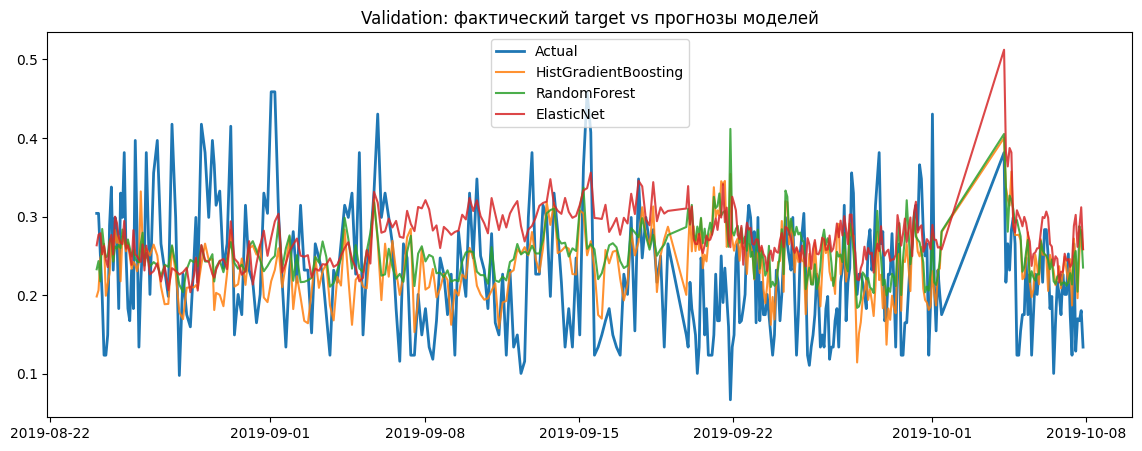

In [32]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_df = train_ds.loc[split_idx:, ["process_time", "target"]].copy()
ax.plot(plot_df["process_time"], plot_df["target"], label="Actual", linewidth=2)

for name in valid_results["model"]:
    plot_df[name] = valid_predictions[name]
    ax.plot(plot_df["process_time"], plot_df[name], label=name, alpha=0.85)

ax.set_title("Validation: фактический target vs прогнозы моделей")
ax.legend()
plt.show()

In [33]:
imputer_for_ols = SimpleImputer(strategy="median")
X_train_imp = imputer_for_ols.fit_transform(X_train)
X_valid_imp = imputer_for_ols.transform(X_valid)

selector = SelectKBest(score_func=f_regression, k=min(20, X_train.shape[1]))
X_train_ols = selector.fit_transform(X_train_imp, y_train)
X_valid_ols = selector.transform(X_valid_imp)

X_train_ols_const = sm.add_constant(X_train_ols)
X_valid_ols_const = sm.add_constant(X_valid_ols)

ols_model = sm.OLS(y_train, X_train_ols_const).fit()
ols_pred_valid = ols_model.predict(X_valid_ols_const)

print("AIC:", ols_model.aic)
print("BIC:", ols_model.bic)
print("Validation metrics:", regression_metrics(y_valid, ols_pred_valid))
print("Direction metrics:", direction_metrics(y_valid, ols_pred_valid))

AIC: -2840.741661354986
BIC: -2735.6016072131442
Validation metrics: {'MAE': 0.07539427654590022, 'RMSE': np.float64(0.09193502122188138), 'MAPE': np.float64(43.4838632126795), 'WAPE': np.float64(33.37556693373709), 'R2': -0.4485812321116358}
Direction metrics: {'directional_accuracy': np.float64(0.5282485875706214), 'up_recall': np.float64(0.5454545454545454), 'down_recall': np.float64(0.5705882352941176)}


### Аналитический вывод по моделям

1. Линейные модели полезны как интерпретируемый baseline, но ограничены при сложных нелинейных режимах процесса.
2. Деревья и бустинг лучше захватывают нелинейные зависимости и взаимодействия между лагами.
3. OLS оставляется как статистическая reference-модель для AIC/BIC.
4. Для практического использования наиболее интересна модель, которая одновременно дает хорошую точность и приемлемое время обучения.

In [34]:
X_train_full = train_ds[feature_cols]
y_train_full = train_ds["target"]

test_results = []
test_predictions = {}
final_models = {}

for name, model in models.items():
    t0 = perf_counter()
    model.fit(X_train_full, y_train_full)
    train_seconds = perf_counter() - t0

    pred_test = model.predict(X_test)

    row = {"model": name, "train_time_sec": train_seconds}
    row.update(regression_metrics(y_test, pred_test))
    row.update(direction_metrics(y_test, pred_test))

    test_results.append(row)
    test_predictions[name] = pred_test
    final_models[name] = model

test_results = pd.DataFrame(test_results).sort_values(["MAE", "RMSE"])
test_results

,model,train_time_sec,MAE,RMSE,MAPE,WAPE,R2,directional_accuracy,up_recall,down_recall
2,HistGradientBoosting,6.686761,0.061783,0.076587,33.275770,29.462372,0.091678,0.529968,0.534247,0.580645
1,RandomForest,47.042057,0.061791,0.076250,34.380020,29.466051,0.099638,0.542587,0.575342,0.567742
0,ElasticNet,0.379406,0.067322,0.080266,38.804909,32.103480,0.002310,0.533123,0.541096,0.580645


In [35]:
best_model_name = test_results.iloc[0]["model"]
best_model = final_models[best_model_name]
best_pred_test = test_predictions[best_model_name]

print("Best model on test_small:", best_model_name)

Best model on test_small: HistGradientBoosting


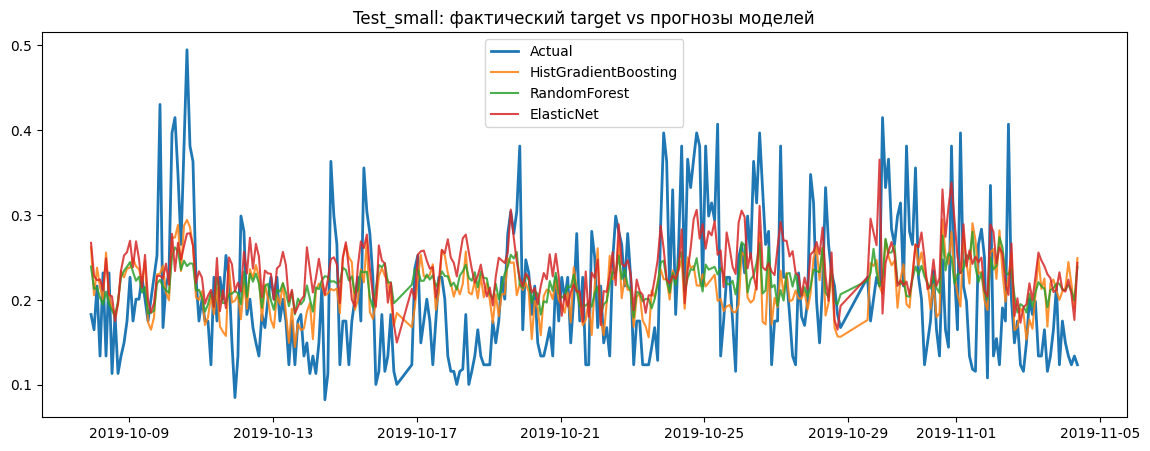

In [37]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_df = test_ds[["process_time", "target"]].copy()
ax.plot(plot_df["process_time"], plot_df["target"], label="Actual", linewidth=2)

for name in test_results["model"]:
    ax.plot(plot_df["process_time"], test_predictions[name], label=name, alpha=0.85)

ax.set_title("Test_small: фактический target vs прогнозы моделей")
ax.legend()
plt.show()

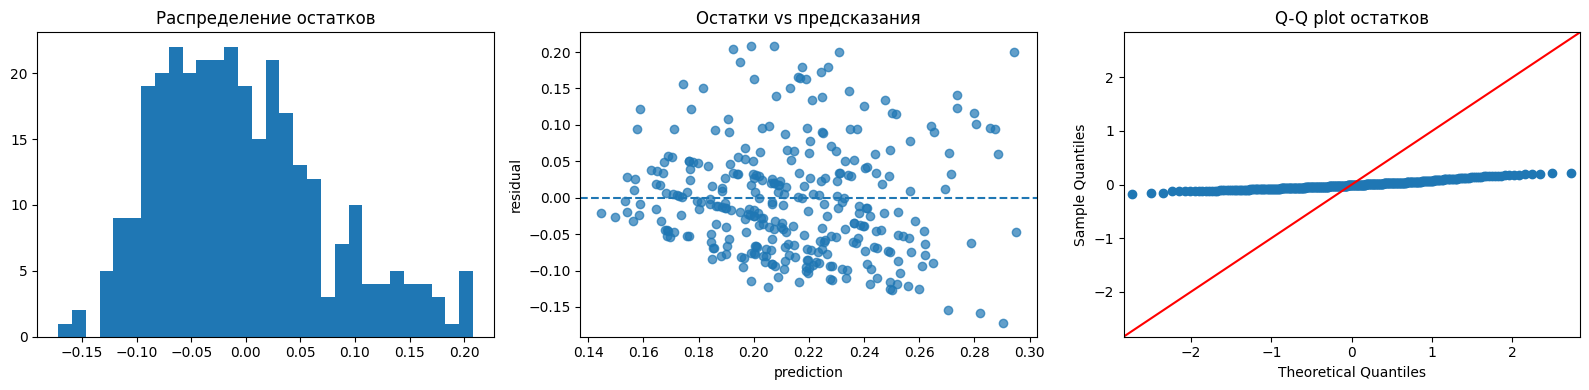

In [38]:
residuals = y_test.values - best_pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(residuals, bins=30)
axes[0].set_title("Распределение остатков")

axes[1].scatter(best_pred_test, residuals, alpha=0.7)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Остатки vs предсказания")
axes[1].set_xlabel("prediction")
axes[1].set_ylabel("residual")

sm.qqplot(residuals, line="45", ax=axes[2])
axes[2].set_title("Q-Q plot остатков")

plt.tight_layout()
plt.show()

In [39]:
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)
lb = acorr_ljungbox(residuals, lags=[5, 10, 20], return_df=True)

X_bp = sm.add_constant(SimpleImputer(strategy="median").fit_transform(X_test))
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, X_bp)

print("Jarque-Bera p-value:", jb_pvalue)
print("\nLjung-Box:")
print(lb)
print("\nBreusch-Pagan p-value:", bp_pvalue)

Jarque-Bera p-value: 3.361769959045411e-05

Ljung-Box:
       lb_stat     lb_pvalue
5   118.009328  8.284883e-24
10  171.089740  1.649842e-31
20  194.461560  1.397570e-30

Breusch-Pagan p-value: 0.9921401966153092


### Интерпретация тестов остатков

- **Jarque-Bera** проверяет нормальность распределения остатков.
- **Ljung-Box** проверяет наличие автокорреляции остатков.
- **Breusch-Pagan** проверяет гетероскедастичность.

Если остатки автокоррелированы, значит модель еще не полностью захватила временную структуру.
Если присутствует гетероскедастичность, это может означать, что в разных режимах печи ошибка модели различается.

In [40]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(20)

,feature,importance_mean,importance_std
11,telemetry_15_ffill,0.002290,0.000807
8,telemetry_12_ffill,0.000442,0.000630
30,telemetry_0_rollmin_15,0.000391,0.000137
65,telemetry_3_rollmin_60,0.000383,0.000142
45,telemetry_0_pct_60,0.000367,0.000142
63,telemetry_3_rollmean_60,0.000323,0.000281
37,telemetry_0_rollstd_60,0.000301,0.000236
104,telemetry_6_lag_60,0.000261,0.000068
48,telemetry_3_lag_15,0.000228,0.000185
20,telemetry_0_lag_5,0.000221,0.000071


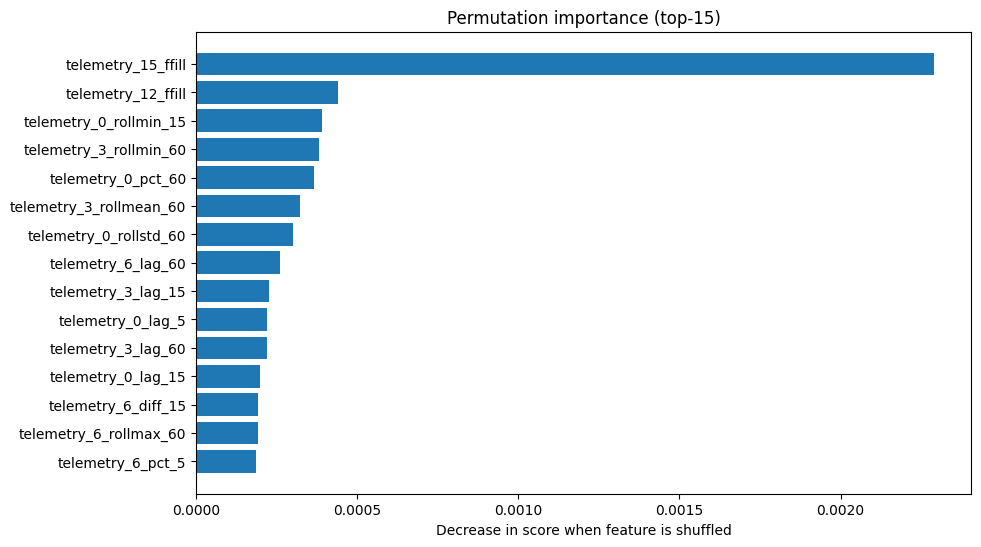

In [41]:
top_imp = importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(10, 6))
plt.barh(top_imp["feature"], top_imp["importance_mean"])
plt.title("Permutation importance (top-15)")
plt.xlabel("Decrease in score when feature is shuffled")
plt.show()

### Физическая интерпретация важных признаков

Если среди наиболее важных признаков встречаются:
- лаги телеметрических каналов,
- rolling mean / rolling std,
- признаки скоростей изменения,

то это физически осмысленно.

Качество продукта в печи зависит:
1. не только от текущего состояния,
2. но и от того, как долго система находилась в данном режиме,
3. а также от стабильности или нестабильности технологических параметров.

## Итоговые выводы

### По пункту 2.1 — EDA
1. Телеметрия минутная, но содержит дубликаты и каналы с разной плотностью наблюдений.
2. Лабораторные измерения редкие и нерегулярные.
3. Обработка пропусков должна быть разной для плотных и редких каналов.

### По пункту 2.2 — инжиниринг признаков
1. Для прогноза текущего качества необходимо учитывать историю процесса.
2. Лаги, rolling statistics и признаки динамики отражают инерционность обжига.
3. Признаки редких каналов лучше задавать через последнее значение и его возраст.

### По пункту 2.3 — модели
1. ElasticNet, RandomForest и HistGradientBoosting подходят для этой задачи.
2. OLS полезна как интерпретируемая статистическая reference-модель.
3. ARIMA только по target и случайная разбивка не подходят как основное решение.

### По пункту 2.4 — оценка и интерпретация
1. Помимо точечных метрик важно учитывать направление изменения target во времени.
2. Анализ остатков позволяет проверить, осталась ли в ошибках систематическая структура.
3. Важности признаков дают физически интерпретируемое объяснение работы модели.